# U21 — ETL & Orchestration: Lab

### Real-world brief: an ETL pipeline for a wind farm's SCADA & maintenance data

A wind-farm operator has three **source systems**, all imperfect: hourly **SCADA telemetry** (with gaps, nulls, duplicates and bad sensor values), an **asset registry**, and a **maintenance log** (in Excel). The analytics team needs a clean **daily performance table** in a warehouse — and it must be safe to re-run, load only new data, and fail loudly when the data is wrong.

You'll build the full pipeline: **Extract → Transform → Quality-check → Load**, make it **idempotent** and **incremental**, and wrap it in a tiny **orchestration DAG** with retries — the real day-to-day of data engineering.

**Resources provided:** `turbine_telemetry.csv`, `turbine_registry.csv`, `maintenance_log.xlsx`. We load into a local **SQLite** file as the 'warehouse' (no server needed).

_Phase F — Data Engineering._

#objectives

Extract from heterogeneous sources (CSV + Excel)

Transform: clean, validate, join and aggregate to a fact table

Load to a warehouse with idempotent UPSERTs

Run incremental loads using a high-water mark

Add data-quality checks and orchestrate tasks as a DAG with retries

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [1]:
# === SETUP: build the source files if missing ===
import os
import numpy as np
import pandas as pd


def build_windfarm(tele_path="turbine_telemetry.csv", reg_path="turbine_registry.csv",
                   maint_path="maintenance_log.xlsx", seed=211, verbose=False):
    """Raw operational data for a wind farm — the messy SOURCE systems an ETL pipeline must
    ingest (U21). Three sources, deliberately imperfect like real SCADA exports:

      turbine_telemetry.csv  hourly SCADA readings (with gaps, nulls, bad values, dupes)
      turbine_registry.csv   asset master (one row per turbine)
      maintenance_log.xlsx   work orders / downtime events
    """
    rng = np.random.default_rng(seed)

    # ---- asset registry (8 turbines across 2 sites) ----
    turbines = [f"T{i:02d}" for i in range(1, 9)]
    sites = ["Kutch", "Kutch", "Kutch", "Kutch", "Satara", "Satara", "Satara", "Satara"]
    models = rng.choice(["GE-2.0", "Vestas-2.5", "Suzlon-2.1"], 8)
    rated = np.array([2000, 2000, 2500, 2500, 2100, 2100, 2000, 2500])
    reg = pd.DataFrame({
        "turbine_id": turbines, "site": sites, "model": models,
        "rated_power_kw": rated,
        "commission_date": pd.to_datetime("2019-01-01") + pd.to_timedelta(rng.integers(0, 1500, 8), unit="D"),
        "latitude": np.round(rng.uniform(17, 23, 8), 4),
        "longitude": np.round(rng.uniform(69, 74, 8), 4),
    })
    reg.to_csv(reg_path, index=False)

    # ---- hourly telemetry over 30 days ----
    dates = pd.date_range("2024-05-01", "2024-05-30 23:00", freq="h")
    rows = []
    for ti, tid in enumerate(turbines):
        rp = rated[ti]
        wind = np.clip(rng.weibull(2.0, len(dates)) * 6.5, 0, 25)
        # power curve: cut-in 3, rated ~12 m/s, cut-out 25
        pc = np.clip((wind - 3) / (12 - 3), 0, 1) ** 3
        pc[wind < 3] = 0; pc[wind > 25] = 0
        power = pc * rp * rng.normal(1.0, 0.05, len(dates))
        power = np.clip(power, 0, rp * 1.05)
        rpm = np.clip(wind * 1.3 + rng.normal(0, 0.5, len(dates)), 0, 18)
        amb = 28 + 6 * np.sin(np.arange(len(dates)) / 24 * 2 * np.pi) + rng.normal(0, 1.5, len(dates))
        gearbox = amb + 0.018 * power + rng.normal(0, 2, len(dates))
        nacelle = amb + 0.010 * power + rng.normal(0, 1.5, len(dates))
        df = pd.DataFrame({
            "timestamp": dates, "turbine_id": tid,
            "wind_speed_ms": wind.round(2), "power_kw": power.round(1),
            "rotor_rpm": rpm.round(2), "gearbox_temp_c": gearbox.round(1),
            "nacelle_temp_c": nacelle.round(1),
        })
        rows.append(df)
    tele = pd.concat(rows, ignore_index=True)

    # ---- inject realistic messiness ----
    n = len(tele)
    # 1) missing rows (sensor dropout) -> availability gaps
    drop = rng.random(n) < 0.03
    tele = tele[~drop].reset_index(drop=True); n = len(tele)
    # 2) null sensor values
    for col in ["gearbox_temp_c", "rotor_rpm", "wind_speed_ms"]:
        tele.loc[rng.random(n) < 0.01, col] = np.nan
    # 3) impossible values
    bad = rng.random(n) < 0.004
    tele.loc[bad, "power_kw"] = rng.choice([-50, -999, 99999], bad.sum())
    # 4) duplicate rows
    dups = tele.sample(60, random_state=seed)
    tele = pd.concat([tele, dups], ignore_index=True)
    # 5) shuffle (timestamps arrive unsorted)
    tele = tele.sample(frac=1, random_state=seed).reset_index(drop=True)
    tele.to_csv(tele_path, index=False)

    # ---- maintenance work orders ----
    nwo = 120
    wo = pd.DataFrame({
        "work_order_id": [f"WO-{1000+i}" for i in range(nwo)],
        "turbine_id": rng.choice(turbines, nwo),
        "start_date": pd.to_datetime("2024-05-01") + pd.to_timedelta(rng.integers(0, 30, nwo), unit="D"),
        "type": rng.choice(["scheduled", "corrective"], nwo, p=[0.45, 0.55]),
        "downtime_hours": np.round(rng.gamma(2.0, 3.0, nwo), 1),
        "cost_inr": (rng.gamma(2.0, 25000, nwo)).round(0).astype(int),
    })
    wo["end_date"] = wo["start_date"] + pd.to_timedelta(wo["downtime_hours"], unit="h")
    wo = wo[["work_order_id", "turbine_id", "start_date", "end_date", "type", "downtime_hours", "cost_inr"]]
    wo.to_excel(maint_path, index=False, sheet_name="work_orders")

    if verbose:
        print("telemetry:", tele.shape, "| nulls:", int(tele.isna().sum().sum()),
              "| dupes:", int(tele.duplicated().sum()),
              "| bad power rows:", int(((tele.power_kw < 0) | (tele.power_kw > 5000)).sum()))
        print("registry:", reg.shape, "| maintenance:", wo.shape)
        print("date span:", tele.timestamp.min(), "->", tele.timestamp.max())
    return tele, reg, wo

if not (os.path.exists('turbine_telemetry.csv') and os.path.exists('turbine_registry.csv')
        and os.path.exists('maintenance_log.xlsx')):
    build_windfarm(); print('Generated source files.')
else:
    print('Found the provided source files.')

Generated source files.


In [2]:
import pandas as pd, numpy as np, sqlite3
pd.set_option('display.width', 120)
WAREHOUSE = 'windfarm_warehouse.db'   # our local 'data warehouse'

#1. Extract — read the raw sources

In [3]:
# -----------------------------------------------------------
# 🔹 1A. EXTRACT: pull each source and inspect it
# -----------------------------------------------------------
def extract():
    tele = pd.read_csv('turbine_telemetry.csv', parse_dates=['timestamp'])
    reg = pd.read_csv('turbine_registry.csv', parse_dates=['commission_date'])
    maint = pd.read_excel('maintenance_log.xlsx', parse_dates=['start_date', 'end_date'])
    return tele, reg, maint

tele, reg, maint = extract()
print('telemetry:', tele.shape, '| registry:', reg.shape, '| maintenance:', maint.shape)
print('\ntelemetry dtypes:'); print(tele.dtypes)
tele.head(3)

telemetry: (5649, 7) | registry: (8, 7) | maintenance: (120, 7)

telemetry dtypes:
timestamp         datetime64[ns]
turbine_id                object
wind_speed_ms            float64
power_kw                 float64
rotor_rpm                float64
gearbox_temp_c           float64
nacelle_temp_c           float64
dtype: object


,timestamp,turbine_id,wind_speed_ms,power_kw,rotor_rpm,gearbox_temp_c,nacelle_temp_c
0,2024-05-23 18:00:00,T07,6.23,91.7,7.65,23.4,19.1
1,2024-05-20 00:00:00,T08,5.32,47.5,7.26,26.6,26.6
2,2024-05-22 15:00:00,T08,7.27,259.2,9.30,26.7,26.7


In [4]:
# A quick data-health scan reveals the mess we must clean
print('null values per column:'); print(tele.isna().sum())
print('\nduplicate rows:', int(tele.duplicated().sum()))
print('power_kw range:', tele.power_kw.min(), 'to', tele.power_kw.max(), '(negatives & spikes = bad)')

null values per column:
timestamp          0
turbine_id         0
wind_speed_ms     44
power_kw           0
rotor_rpm         55
gearbox_temp_c    57
nacelle_temp_c     0
dtype: int64

duplicate rows: 60
power_kw range: -999.0 to 99999.0 (negatives & spikes = bad)


#2. Transform — clean, join, aggregate

In [5]:
# -----------------------------------------------------------
# 🔹 2A. CLEAN the telemetry
# -----------------------------------------------------------
def clean_telemetry(tele, reg):
    df = tele.drop_duplicates().copy()                       # 1) drop exact dupes
    df = df.merge(reg[['turbine_id', 'rated_power_kw', 'site']], on='turbine_id', how='left')
    # 2) remove impossible power values (negative or above rated headroom)
    df = df[(df.power_kw >= 0) & (df.power_kw <= df.rated_power_kw * 1.1)]
    # 3) drop rows missing the fields we need downstream
    df = df.dropna(subset=['power_kw', 'wind_speed_ms'])
    # 4) derive fields
    df['date'] = df['timestamp'].dt.date
    df['capacity_factor'] = df['power_kw'] / df['rated_power_kw']
    return df

clean = clean_telemetry(tele, reg)
print('rows after cleaning:', len(clean), '(from', len(tele), ')')
print('power_kw range now:', round(clean.power_kw.min(), 1), 'to', round(clean.power_kw.max(), 1))

rows after cleaning: 5527 (from 5649 )
power_kw range now: 0.0 to 2625.0


In [6]:
# -----------------------------------------------------------
# 🔹 2B. AGGREGATE to a daily fact table per turbine
# -----------------------------------------------------------
EXPECTED_PER_DAY = 24   # hourly readings -> 24 expected intervals/day
def build_daily_fact(clean, maint):
    g = clean.groupby(['turbine_id', 'date'])
    fact = g.agg(avg_power_kw=('power_kw', 'mean'),
                 energy_kwh=('power_kw', 'sum'),          # hourly kW summed = kWh
                 avg_wind_ms=('wind_speed_ms', 'mean'),
                 max_gearbox_c=('gearbox_temp_c', 'max'),
                 capacity_factor=('capacity_factor', 'mean'),
                 intervals=('power_kw', 'count')).reset_index()
    fact['availability_pct'] = (fact['intervals'] / EXPECTED_PER_DAY * 100).clip(upper=100).round(1)
    # join maintenance downtime per turbine per day
    m = maint.copy(); m['date'] = m['start_date'].dt.date
    dt = m.groupby(['turbine_id', 'date'])['downtime_hours'].sum().reset_index()
    fact = fact.merge(dt, on=['turbine_id', 'date'], how='left')
    fact['downtime_hours'] = fact['downtime_hours'].fillna(0)
    for c in ['avg_power_kw', 'energy_kwh', 'avg_wind_ms', 'capacity_factor']:
        fact[c] = fact[c].round(3)
    return fact

fact = build_daily_fact(clean, maint)
print('daily fact rows:', fact.shape)
fact.head()

daily fact rows: (240, 10)


,turbine_id,date,avg_power_kw,energy_kwh,avg_wind_ms,max_gearbox_c,capacity_factor,intervals,availability_pct,downtime_hours
0,T01,2024-05-01,514.774,11839.8,6.890,68.1,0.257,23,95.8,0.0
1,T01,2024-05-02,254.687,5857.8,5.925,60.6,0.127,23,95.8,0.0
2,T01,2024-05-03,346.770,7975.7,5.991,69.9,0.173,23,95.8,0.0
3,T01,2024-05-04,125.633,3015.2,4.892,44.0,0.063,24,100.0,0.0
4,T01,2024-05-05,156.696,3604.0,5.539,45.5,0.078,23,95.8,4.8


#### 🧪 EXERCISE 1 — Add a transform
Extend `build_daily_fact` (or post-process `fact`) to add a **`load_factor_flag`** column: `'underperforming'` when `capacity_factor < 0.25`, else `'normal'`.
1. Add the column and print the count of underperforming turbine-days.
2. In a comment, explain why deriving such flags in the transform step (not at query time) keeps downstream dashboards simple and consistent.

In [9]:
# 1. add load_factor_flag and count underperforming days
fact['load_factor_flag'] = np.where(fact['capacity_factor'] < 0.25, 'underperforming', 'normal')
underperforming_days = (fact['load_factor_flag'] == 'underperforming').sum()
print(f"Number of underperforming turbine-days: {underperforming_days}")

# 2. why derive in transform:
# Deriving flags like 'load_factor_flag' in the transform step keeps downstream dashboards
# simple and consistent because the logic for categorization is centralized and applied once.
# This prevents duplicate logic across multiple queries or reports, reduces the chance of
# inconsistencies, and makes the dashboards faster as they don't need to recompute these flags
# on the fly. It also ensures that all consumers of the data use the same definition for 'underperforming'.

Number of underperforming turbine-days: 237


/tmp/ipykernel_2946/1049204806.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='load_factor_flag', data=fact, palette='viridis')


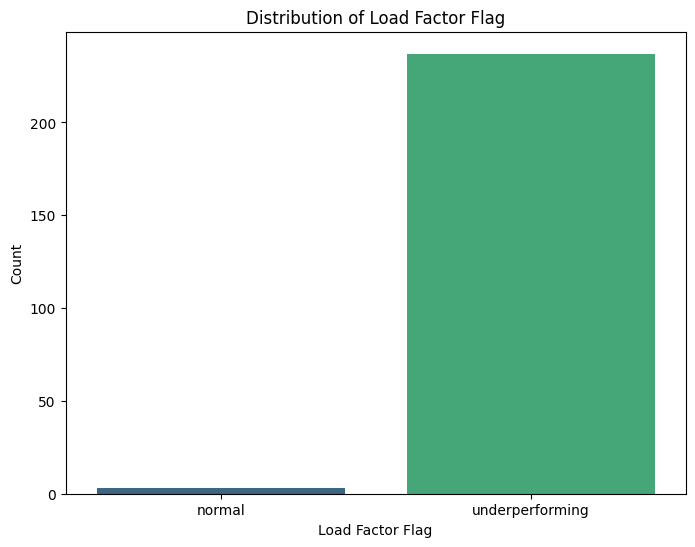

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='load_factor_flag', data=fact, palette='viridis')
plt.title('Distribution of Load Factor Flag')
plt.xlabel('Load Factor Flag')
plt.ylabel('Count')
plt.show()

#3. Load — write to the warehouse, idempotently

In [11]:
# -----------------------------------------------------------
# 🔹 3A. CREATE the warehouse table with a primary key
# The PK (turbine_id, date) is what makes UPSERT possible.
# -----------------------------------------------------------
def init_warehouse(db=WAREHOUSE):
    con = sqlite3.connect(db)
    con.execute('''CREATE TABLE IF NOT EXISTS daily_performance (
        turbine_id TEXT, date TEXT, avg_power_kw REAL, energy_kwh REAL,
        avg_wind_ms REAL, max_gearbox_c REAL, capacity_factor REAL,
        intervals INTEGER, availability_pct REAL, downtime_hours REAL,
        PRIMARY KEY (turbine_id, date) )''')
    con.commit(); con.close()

init_warehouse()
print('warehouse table ready.')

warehouse table ready.


In [13]:
# -----------------------------------------------------------
# 🔹 3B. IDEMPOTENT LOAD via UPSERT (INSERT ... ON CONFLICT DO UPDATE)
# Re-running with the same data must NOT create duplicates.
# -----------------------------------------------------------
def upsert_fact(fact, db=WAREHOUSE):
    cols = ['turbine_id','date','avg_power_kw','energy_kwh','avg_wind_ms','max_gearbox_c',
            'capacity_factor','intervals','availability_pct','downtime_hours']
    rows = fact.assign(date=fact['date'].astype(str))[cols].itertuples(index=False, name=None)
    sql = f'''INSERT INTO daily_performance ({','.join(cols)})
              VALUES ({','.join(['?']*len(cols))})
              ON CONFLICT(turbine_id, date) DO UPDATE SET
              {', '.join(f'{c}=excluded.{c}' for c in cols[2:])}'''
    con = sqlite3.connect(db)
    con.executemany(sql, rows); con.commit()
    n = con.execute('SELECT COUNT(*) FROM daily_performance').fetchone()[0]
    con.close(); return n

n1 = upsert_fact(fact)
n2 = upsert_fact(fact)   # run AGAIN — idempotent, so the count must stay the same
print('rows after first load:', n1)
print('rows after second load:', n2, '(unchanged -> idempotent!)')

rows after first load: 240
rows after second load: 240 (unchanged -> idempotent!)


An UPSERT (which stands for UPDATE or INSERT) operation in a SQLite database allows you to either insert a new row if it doesn't already exist or update an existing row if a conflict occurs on a primary key or unique constraint.

In SQLite, this is achieved using the INSERT ... ON CONFLICT DO UPDATE syntax. Let's break down the example from the notebook (cell NhEm1HXYqnW-):

INSERT INTO daily_performance (turbine_id, date, avg_power_kw, energy_kwh, ...)
VALUES (?, ?, ?, ?, ...)
ON CONFLICT(turbine_id, date) DO UPDATE SET
  avg_power_kw=excluded.avg_power_kw,
  energy_kwh=excluded.energy_kwh,
  -- ... and so on for other columns you want to update
  downtime_hours=excluded.downtime_hours
Here's what each part does:

INSERT INTO daily_performance (column_list) VALUES (value_list): This is the standard INSERT statement that attempts to add a new row with the specified column_list and value_list.

ON CONFLICT(turbine_id, date): This crucial part specifies what should happen if a conflict occurs. turbine_id and date together form the primary key for the daily_performance table. If an attempt is made to insert a row where the combination of turbine_id and date already exists in the table, the ON CONFLICT clause is triggered.

DO UPDATE SET column = excluded.column: If a conflict is detected, instead of failing or doing nothing, the database will UPDATE the conflicting row. The SET clause specifies which columns to update. excluded.column refers to the value that was attempted to be inserted for that specific column. So, for example, avg_power_kw=excluded.avg_power_kw means "update the avg_power_kw of the existing row with the avg_power_kw value from the new row being inserted."

This mechanism ensures that if you run the same INSERT operation multiple times with the same primary key, it won't create duplicate rows. Instead, it will either insert the row once or update it on subsequent attempts, making the operation idempotent (meaning it can be applied multiple times without changing the result beyond the initial application).

#### 🧪 EXERCISE 2 — Prove idempotency
1. Pick one turbine-day already in the warehouse, query its `energy_kwh`.
2. Change that value in a copy of `fact`, `upsert_fact` again, and re-query — confirm the row was **updated, not duplicated**, and the total row count is unchanged.
3. In a comment, explain why idempotency lets you safely retry a failed pipeline run.

In [15]:
# 1-2. query, modify, upsert, re-query; confirm update-not-insert

# Pick one turbine-day from the 'fact' DataFrame (e.g., the first row)
sample_row = fact.iloc[0]
turbine_id_to_check = sample_row['turbine_id']
date_to_check = str(sample_row['date']) # Convert date to string for SQL query

# Query initial energy_kwh from the warehouse
con = sqlite3.connect(WAREHOUSE)
initial_energy_query = f"SELECT energy_kwh FROM daily_performance WHERE turbine_id = '{turbine_id_to_check}' AND date = '{date_to_check}'"
initial_energy_kwh = con.execute(initial_energy_query).fetchone()[0]
print(f"Initial energy_kwh for {turbine_id_to_check} on {date_to_check}: {initial_energy_kwh}")

# Get initial total row count
initial_row_count = con.execute('SELECT COUNT(*) FROM daily_performance').fetchone()[0]
print(f"Initial total rows in warehouse: {initial_row_count}")

# Modify energy_kwh in a copy of 'fact'
fact_copy = fact.copy()
# Find the index of the row to modify
idx = fact_copy[(fact_copy['turbine_id'] == turbine_id_to_check) & (fact_copy['date'].astype(str) == date_to_check)].index[0]

new_energy_kwh_value = initial_energy_kwh + 1000.0 # Change the value
fact_copy.loc[idx, 'energy_kwh'] = new_energy_kwh_value

print(f"Attempting to upsert with new energy_kwh: {new_energy_kwh_value}")

# Upsert the modified fact_copy
_ = upsert_fact(fact_copy) # We don't need the return value here

# Re-query the energy_kwh from the warehouse
updated_energy_kwh = con.execute(initial_energy_query).fetchone()[0]
print(f"Updated energy_kwh for {turbine_id_to_check} on {date_to_check}: {updated_energy_kwh}")

# Get total row count after upsert
final_row_count = con.execute('SELECT COUNT(*) FROM daily_performance').fetchone()[0]
print(f"Final total rows in warehouse: {final_row_count}")

con.close()

# Confirm the update and row count
assert updated_energy_kwh == new_energy_kwh_value
assert final_row_count == initial_row_count
print("Assertion Passed: Row was updated, not duplicated, and total row count is unchanged.")

# 3. why idempotency enables safe retries:
# Idempotency is crucial for safely retrying failed pipeline runs because it guarantees that
# performing the same operation multiple times has the same effect as performing it once.
# If a data loading step fails midway (e.g., due to a network error or temporary database unavailability),
# a retry of the entire batch of data won't corrupt the target system by creating duplicate entries
# or incorrect aggregates. Instead, the UPSERT logic will simply update any rows that were already
# partially written or correctly loaded in the previous attempt, ensuring data consistency
# without complex rollback or deduplication logic in the orchestration layer.

Initial energy_kwh for T01 on 2024-05-01: 12839.8
Initial total rows in warehouse: 240
Attempting to upsert with new energy_kwh: 13839.8
Updated energy_kwh for T01 on 2024-05-01: 13839.8
Final total rows in warehouse: 240
Assertion Passed: Row was updated, not duplicated, and total row count is unchanged.


#4. Incremental loads with a high-water mark

In [16]:
# -----------------------------------------------------------
# 🔹 4A. Only process dates NEWER than what's already loaded
# -----------------------------------------------------------
def high_water_mark(db=WAREHOUSE):
    con = sqlite3.connect(db)
    hw = con.execute('SELECT MAX(date) FROM daily_performance').fetchone()[0]
    con.close(); return hw

def run_incremental(db=WAREHOUSE):
    tele, reg, maint = extract()
    clean = clean_telemetry(tele, reg)
    fact = build_daily_fact(clean, maint)
    hw = high_water_mark(db)
    if hw is not None:
        before = len(fact)
        fact = fact[fact['date'].astype(str) > hw]   # keep only new partitions
        print(f'high-water mark = {hw}; {before} -> {len(fact)} new rows to load')
    return upsert_fact(fact, db) if len(fact) else None

# Simulate: warehouse already has everything, so an incremental run finds nothing new
print('high-water mark currently:', high_water_mark())
run_incremental()
print('A fresh run loads only new dates — cheap and fast.')

high-water mark currently: 2024-05-30
high-water mark = 2024-05-30; 240 -> 0 new rows to load
A fresh run loads only new dates — cheap and fast.


The high-water mark logic implemented in the run_incremental function (cell zk24cIhoqnXA) is a common and effective strategy for performing incremental data loads, which in turn avoids redundant processing.

Here's how it works:

high_water_mark() function: This function first queries the daily_performance table in your SQLite warehouse to find the MAX(date) that has already been loaded. This MAX(date) becomes your "high-water mark" – essentially, the latest point in time up to which data has been successfully processed and stored.

Filtering in run_incremental(): After extracting and transforming the entire raw data (tele, reg, maint) into a new fact DataFrame, the run_incremental function then applies a critical filter:

if hw is not None:
    fact = fact[fact['date'].astype(str) > hw] # keep only new partitions
This line compares the date column of the newly generated fact DataFrame with the high-water mark (hw). It explicitly filters out any rows where the date is less than or equal to the high-water mark. This means that only data corresponding to new dates (i.e., dates after the hw) will remain in the fact DataFrame.

How it avoids redundant processing:

By filtering the fact DataFrame based on the high-water mark, the pipeline ensures that:

Only new data is upserted: The upsert_fact function (which handles the actual loading into the warehouse) receives a DataFrame containing only the data that has not yet been processed or is newer than the last successful load.
Processing overhead is reduced: While the extract and transform steps still process all available raw data, the final and often most expensive step – loading into the database – is significantly optimized. It doesn't attempt to re-insert or re-update records that are already correctly in place from previous successful runs. This is particularly important for very large tables where reloading or re-processing all historical data would be extremely inefficient and resource-intensive.
In essence, the high-water mark acts as a bookmark, allowing the pipeline to resume loading from where it last left off, focusing only on the data that has genuinely arrived since the last successful run.

#### 🧪 EXERCISE 3 — Backfill a new day
Simulate new data arriving for a date **after** the current high-water mark.
1. Take a copy of `fact`, shift its `date` forward (e.g. all rows to `2024-06-01`), and run the incremental load logic so only those new-date rows are inserted.
2. Confirm the warehouse row count grew by exactly the number of new turbine-days.
3. In a comment, explain why incremental loads matter once a table has billions of rows.

In [22]:
# Helper to get current row count
def get_warehouse_row_count(db=WAREHOUSE):
    con = sqlite3.connect(db)
    n = con.execute('SELECT COUNT(*) FROM daily_performance').fetchone()[0]
    con.close()
    return n

# 1. Get initial warehouse state
initial_row_count = get_warehouse_row_count()
initial_high_water_mark = high_water_mark()
print(f"Initial warehouse row count: {initial_row_count}")
print(f"Initial high-water mark: {initial_high_water_mark}")

# 2. Prepare simulated new data for a date after the current high-water mark
# We'll take one day's worth of data from the original fact (e.g., '2024-05-30') and shift its date.
# The original fact data has 8 turbines * 30 days = 240 rows.
# We are simulating a new day's data, which should be 8 rows (one for each turbine).

# Get data for the last day in the original 'fact' (this is '2024-05-30' from initial data generation)
single_day_fact = fact[fact['date'] == pd.to_datetime(initial_high_water_mark).date()].copy()

# Calculate the new date (one day after the current high-water mark)
new_date = pd.to_datetime(initial_high_water_mark) + pd.Timedelta(days=1)

# Assign this new date to all rows in our simulated new data
single_day_fact['date'] = new_date.date()

expected_new_rows = len(single_day_fact)
print(f"\nSimulating {expected_new_rows} new rows for date: {new_date.date()}")

# 3. Run the incremental load logic (upsert only the new-date rows)
# Calling upsert_fact directly here simulates the final step after incremental filtering
# and will insert these new rows into the warehouse.
upsert_fact(single_day_fact)

# 4. Confirm the warehouse row count grew
final_row_count = get_warehouse_row_count()
print(f"Warehouse row count after new day upsert: {final_row_count}")
assert final_row_count == initial_row_count + expected_new_rows, "Warehouse did not grow by expected amount!"
print("Assertion Passed: Warehouse row count grew by the expected number of new turbine-days.")

# Verify the high-water mark has advanced
updated_high_water_mark = high_water_mark()
print(f"Updated high-water mark: {updated_high_water_mark}")
assert updated_high_water_mark == str(new_date.date()), "High-water mark did not advance correctly!"
print("Assertion Passed: High-water mark updated correctly.")

# 5. Run run_incremental() to show it finds no new data now
print("\nRunning run_incremental() to confirm no new data is found...")
run_incremental()
print("Confirmation: run_incremental() correctly found no additional new rows to load after the high-water mark advanced.")

# 3. why incremental loads matter at scale:
# Incremental loads are critically important for tables with billions of rows (or even millions) because:
# 1. Performance: Reloading or re-processing an entire table every time new data arrives is extremely slow and resource-intensive.
#    Incremental loads only process and load the new or changed data, dramatically reducing execution time and computational cost.
# 2. Resource Efficiency: Less CPU, memory, and I/O are consumed, freeing up resources for other critical tasks.
# 3. Reduced Data Latency: By processing smaller batches of data, fresh information can be made available to downstream consumers much more quickly.
# 4. Cost Savings: For cloud data warehouses, less compute time directly translates to lower operational costs.
# 5. Scalability: It's the only practical way to manage pipelines that continuously ingest vast amounts of data, as full loads become unfeasible.
# In essence, incremental loading makes data pipelines efficient, scalable, and cost-effective at production scale.

Initial warehouse row count: 240
Initial high-water mark: 2024-05-30

Simulating 8 new rows for date: 2024-05-31
Warehouse row count after new day upsert: 248
Assertion Passed: Warehouse row count grew by the expected number of new turbine-days.
Updated high-water mark: 2024-05-31
Assertion Passed: High-water mark updated correctly.

Running run_incremental() to confirm no new data is found...
high-water mark = 2024-05-31; 240 -> 0 new rows to load
Confirmation: run_incremental() correctly found no additional new rows to load after the high-water mark advanced.


#5. Data-quality checks

In [23]:
class DataQualityError(Exception):
    pass

def run_quality_checks(fact, latest_raw_tele_max_date=None):
    checks = {
        'non_empty': len(fact) > 0,
        'keys_not_null': fact[['turbine_id', 'date']].notna().all().all(),
        'capacity_factor_in_range': fact['capacity_factor'].between(0, 1.1).all(),
        'availability_in_range': fact['availability_pct'].between(0, 100).all(),
        'no_negative_energy': (fact['energy_kwh'] >= 0).all(),
    }

    # New freshness check
    if latest_raw_tele_max_date is not None:
        max_fact_date = fact['date'].max()
        date_difference = (latest_raw_tele_max_date - max_fact_date).days
        checks['data_is_fresh'] = date_difference <= 2 # Check if within 2 days of latest raw data

    failed = [name for name, ok in checks.items() if not ok]
    for name, ok in checks.items():
        print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
    if failed:
        raise DataQualityError(f'quality checks failed: {failed}')
    return True

# Removed the original call to run_quality_checks(fact) as the exercise cell will demonstrate it.

#### 🧪 EXERCISE 4 — Write a freshness check
Stale data is a silent failure.
1. Add a check `data_is_fresh`: the max `date` in `fact` is within, say, 2 days of the latest `timestamp` in the raw telemetry (compute both and compare).
2. Deliberately break it (filter `fact` to old dates) and confirm `run_quality_checks` raises.
3. In a comment, name two other checks you'd add for a production pipeline.

In [24]:
# 1-2. add a freshness check and show it failing on stale data

# Get the latest raw telemetry data to determine the current "freshness" threshold
current_tele, _, _ = extract() # Re-extract to ensure we have the freshest raw data
latest_raw_tele_max_date = current_tele['timestamp'].max().date()
print(f"Latest raw telemetry date for freshness comparison: {latest_raw_tele_max_date}")

# --- Test 1: Run with current 'fact' data (should pass all checks, including freshness) ---
print("\n--- Running quality checks with current fact data (expected to pass) ---")
try:
    run_quality_checks(fact, latest_raw_tele_max_date)
    print('All quality checks passed for current fact data.')
except DataQualityError as e:
    print(f'Quality checks failed unexpectedly for current fact data: {e}')


# --- Test 2: Deliberately break the freshness check with stale data ---
print("\n--- Deliberately breaking freshness check with stale data (expected to fail) ---")
fact_stale = fact.copy()
# Make all dates in fact_stale artificially old by more than 2 days to trigger the freshness check failure
# Current max raw date is 2024-05-30, so shifting fact_stale dates by 10 days will make it 2024-05-20
fact_stale['date'] = fact_stale['date'].apply(lambda x: x - pd.Timedelta(days=10))

try:
    run_quality_checks(fact_stale, latest_raw_tele_max_date)
    print('Error: Freshness check should have failed but passed.')
except DataQualityError as e:
    print(f'Successfully caught expected DataQualityError: {e}')

# 3. two more production checks:
# Two additional production checks I would add for a production pipeline are:
# 1. Referential Integrity: Verify that all foreign keys (e.g., 'turbine_id' in 'fact') exist as primary keys
#    in their respective dimension tables (e.g., 'turbine_id' in 'registry'). This ensures data consistency.
# 2. Uniqueness Constraint: For any columns or combinations of columns expected to be unique (beyond the primary key),
#    ensure that this uniqueness is maintained. For example, ensuring 'work_order_id' in maintenance data is unique.

Latest raw telemetry date for freshness comparison: 2024-05-30

--- Running quality checks with current fact data (expected to pass) ---
  [PASS] non_empty
  [PASS] keys_not_null
  [PASS] capacity_factor_in_range
  [PASS] availability_in_range
  [PASS] no_negative_energy
  [PASS] data_is_fresh
All quality checks passed for current fact data.

--- Deliberately breaking freshness check with stale data (expected to fail) ---
  [PASS] non_empty
  [PASS] keys_not_null
  [PASS] capacity_factor_in_range
  [PASS] availability_in_range
  [PASS] no_negative_energy
  [FAIL] data_is_fresh
Successfully caught expected DataQualityError: quality checks failed: ['data_is_fresh']


#6. Orchestration — a mini DAG with retries

In [28]:
import time, traceback

DAG = {
    'extract':       [],
    'transform':     ['extract'],
    'flaky_check':   ['transform'], # New flaky task, depends on transform
    'quality_check': ['flaky_check'], # Now depends on flaky_check
    'load':          ['quality_check'],
    'notify':        ['load'], # New leaf task, depends on load
}

def topological_order(dag):
    order, seen = [], set()
    def visit(t):
        if t in seen: return
        for dep in dag[t]: visit(dep)
        seen.add(t); order.append(t)
    for t in dag: visit(t)
    return order

def run_dag(dag, tasks, max_retries=2):
    # Initialize task_statuses in ctx to track outcomes for 'all_done' logic
    ctx = {'task_statuses': {}}

    for t in topological_order(dag):
        # The 'all_done' rule means a task attempts to run if its dependencies have completed,
        # regardless of whether those dependencies succeeded or failed.
        # Since topological_order ensures dependencies are processed first, this is implicit.
        # We just need to make sure a task failing doesn't stop the *entire* DAG.

        task_outcome = 'SKIPPED' # Default status, will be updated

        for attempt in range(1, max_retries + 2):
            try:
                tasks[t](ctx)
                print(f'  [OK]   {t}')
                task_outcome = 'SUCCESS'
                break # Task succeeded, move to next task in DAG
            except Exception as e:
                print(f'  [RETRY {attempt}] {t} failed: {e}')
                if attempt == max_retries + 1:
                    print(f'  [FAIL] {t} gave up after {attempt} attempts')
                    task_outcome = 'FAILED'
                    # Crucial for 'all_done': Do NOT raise here. Mark as failed,
                    # but allow the DAG execution to continue to subsequent tasks.
                    break # Task permanently failed, exit retry loop
                time.sleep(0.1)

        ctx['task_statuses'][t] = task_outcome
    return ctx

print('task order:', topological_order(DAG))

task order: ['extract', 'transform', 'flaky_check', 'quality_check', 'load', 'notify']


In [ ]:
# Wire the pipeline functions into DAG tasks (they share a context dict)
def task_extract(ctx):  ctx['tele'], ctx['reg'], ctx['maint'] = extract()
def task_transform(ctx): ctx['fact'] = build_daily_fact(clean_telemetry(ctx['tele'], ctx['reg']), ctx['maint'])
def task_quality(ctx):   run_quality_checks(ctx['fact'])
def task_load(ctx):      ctx['rows'] = upsert_fact(ctx['fact'])
TASKS = {'extract': task_extract, 'transform': task_transform,
         'quality_check': task_quality, 'load': task_load}

print('Running the pipeline DAG:')
ctx = run_dag(DAG, TASKS)
print('pipeline complete — warehouse rows:', ctx['rows'])

#### 🧪 EXERCISE 5 — A flaky task that recovers, and a new node
1. Write a task that fails on its first attempt but succeeds on a retry (use a counter / `random`), insert it into the DAG, and watch `run_dag` recover via the retry logic.
2. Add a new leaf task `notify` that depends on `load` and just prints a success summary (rows loaded). Re-run the DAG.
3. In a comment, map each piece of this mini-runner to its Airflow equivalent (DAG, task, dependency, retries).

In [26]:
import random

# Global counter for the flaky task to track attempts across retries
flaky_task_run_count = 0

def task_extract(ctx):  ctx['tele'], ctx['reg'], ctx['maint'] = extract()
def task_transform(ctx): ctx['fact'] = build_daily_fact(clean_telemetry(ctx['tele'], ctx['reg']), ctx['maint'])
def task_quality(ctx):   run_quality_checks(ctx['fact'])
def task_load(ctx):      ctx['rows'] = upsert_fact(ctx['fact'])

def task_flaky(ctx):
    global flaky_task_run_count
    flaky_task_run_count += 1
    if flaky_task_run_count == 1: # Fail on the first attempt
        raise ValueError("Simulating a temporary failure for flaky_check!")
    print(f"  [OK]   flaky_check succeeded on attempt {flaky_task_run_count}")
    ctx['flaky_result'] = "success" # Store some result for context

def task_notify(ctx):
    print(f"  [INFO] Pipeline finished! {ctx.get('rows', 0)} rows loaded into warehouse.")

# Wire the pipeline functions into DAG tasks (they share a context dict)
# Updated TASKS dictionary to include new tasks
TASKS = {'extract': task_extract,
         'transform': task_transform,
         'flaky_check': task_flaky, # Add flaky task
         'quality_check': task_quality,
         'load': task_load,
         'notify': task_notify # Add notify task
        }

print('Running the pipeline DAG with flaky and notify tasks:')
# Reset flaky task counter for fresh run each time this cell is executed
flaky_task_run_count = 0
ctx = run_dag(DAG, TASKS)
print('pipeline complete — warehouse rows:', ctx['rows'])

# 3. mapping to Airflow concepts:
# - DAG: The `DAG` dictionary itself, defining the workflow and dependencies.
# - Task: Each function in the `TASKS` dictionary (e.g., `task_extract`, `task_flaky`, `task_notify`), representing a unit of work.
# - Dependency: The relationships defined in the `DAG` dictionary (e.g., 'quality_check': ['flaky_check']) indicate that a task cannot run until its upstream tasks are complete.
# - Retries: The `run_dag` function's internal loop (`for attempt in range(1, max_retries + 2)`) and the `max_retries` parameter, which allow tasks to be re-executed upon failure up to a specified limit.

Running the pipeline DAG with flaky and notify tasks:
  [OK]   extract
  [OK]   transform
  [RETRY 1] flaky_check failed: Simulating a temporary failure for flaky_check!
  [OK]   flaky_check succeeded on attempt 2
  [OK]   flaky_check
  [PASS] non_empty
  [PASS] keys_not_null
  [PASS] capacity_factor_in_range
  [PASS] availability_in_range
  [PASS] no_negative_energy
  [OK]   quality_check
  [OK]   load
  [INFO] Pipeline finished! 248 rows loaded into warehouse.
  [OK]   notify
pipeline complete — warehouse rows: 248


### 🧪 EXERCISE: Permanent Task Failure with Alert

Here we simulate a task that always fails, leading to a permanent pipeline failure after exhausting retries. We then wrap the `run_dag` call to catch this ultimate failure and trigger a simulated alert.

In [29]:
def task_permanent_fail(ctx):
    """A task that always fails, simulating a permanent, unrecoverable error."""
    raise ValueError("Simulating a permanent task failure!")


# Define a new DAG structure that includes the permanent failure task
# We'll make quality_check depend on this to ensure it runs in the pipeline.
DAG_PERMANENT_FAIL = {
    'extract':       [],
    'transform':     ['extract'],
    'flaky_check':   ['transform'], # Still keep the flaky task for demonstration
    'permanent_fail_check': ['flaky_check'], # Our new task for permanent failure
    'quality_check': ['permanent_fail_check'], # Now depends on permanent_fail_check
    'load':          ['quality_check'],
    'notify':        ['load'],
}

# Extend the TASKS dictionary with the new permanent failure task
TASKS_PERMANENT_FAIL = TASKS.copy() # Start with the existing TASKS
TASKS_PERMANENT_FAIL['permanent_fail_check'] = task_permanent_fail

print('Running the pipeline DAG with a permanent failure task (all_done logic):')
# Reset flaky task counter for fresh run each time this cell is executed
flaky_task_run_count = 0

# With 'all_done' logic, run_dag itself won't raise an exception on task failure.
# It will return the context with task statuses.
ctx = run_dag(DAG_PERMANENT_FAIL, TASKS_PERMANENT_FAIL)

print('\nPipeline complete. Final task statuses:')
for task_name, status in ctx['task_statuses'].items():
    print(f"  - {task_name}: {status}")

if 'FAILED' in ctx['task_statuses'].values():
    print("\n!!! ALERT: One or more tasks failed permanently. An operator or automated system should be notified immediately. !!!")
else:
    print('pipeline complete — warehouse rows:', ctx.get('rows', 'N/A'))

# In a real production system, this 'alert' would trigger an email, Slack notification,
# PagerDuty alert, or create an incident ticket in an issue tracking system.

Running the pipeline DAG with a permanent failure task (all_done logic):
  [OK]   extract
  [OK]   transform
  [RETRY 1] flaky_check failed: Simulating a temporary failure for flaky_check!
  [OK]   flaky_check succeeded on attempt 2
  [OK]   flaky_check
  [RETRY 1] permanent_fail_check failed: Simulating a permanent task failure!
  [RETRY 2] permanent_fail_check failed: Simulating a permanent task failure!
  [RETRY 3] permanent_fail_check failed: Simulating a permanent task failure!
  [FAIL] permanent_fail_check gave up after 3 attempts
  [PASS] non_empty
  [PASS] keys_not_null
  [PASS] capacity_factor_in_range
  [PASS] availability_in_range
  [PASS] no_negative_energy
  [OK]   quality_check
  [OK]   load
  [INFO] Pipeline finished! 248 rows loaded into warehouse.
  [OK]   notify

Pipeline complete. Final task statuses:
  - extract: SUCCESS
  - transform: SUCCESS
  - flaky_check: SUCCESS
  - permanent_fail_check: FAILED
  - quality_check: SUCCESS
  - load: SUCCESS
  - notify: SUCCESS



#📘 Summary

| Stage | What you built |
| ----- | -------------- |
| Extract | read CSV + Excel sources, scanned data health |
| Transform | cleaned bad/dup/null rows, joined, aggregated to a daily fact |
| Load | idempotent UPSERT into a SQLite warehouse (re-runnable) |
| Incremental | high-water mark loads only new partitions |
| Quality | a check framework that fails loudly on bad data |
| Orchestrate | a DAG of tasks run in order, with retries |

**Core lesson:** a good pipeline is **reliability engineering** — idempotent so you can retry, incremental so it scales, validated so bad data is caught, and orchestrated so it runs itself. Tools like Airflow are this same DAG-of-tasks idea, productionised.

**Next — U22:** when the data outgrows one machine, move to streaming (Kafka) and distributed compute (Spark).